In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy import stats

In [2]:
def read_txt(filename):
    with open(filename, encoding='utf-8') as f:
        lines = f.readlines()
    start = 0
    for i, line in enumerate(lines):
        if '[nm]' in line:
            start = i + 1
            break
    
    colnames = ['Wave', 'Sample', 'Dark', 'Reference', 'Scope']
    
    df = pd.read_csv(
        filename,
        sep=';',
        skiprows=start,
        skipinitialspace=True,
        names=colnames,
        engine='python'
    )

    return df['Wave'], df['Scope']

In [3]:
def red_raman_shift(s):
    return ((1/663) - (1/s)) * pow(10, 7)

def blue_raman_shift(s):
    return ((1/443) - (1/s)) * pow(10, 7)

In [4]:
def resolution_peaks(filename, height, dist):
    
    x, y = read_txt(filename)
    x = x.values
    y = y.values
    
    peaks, _ = find_peaks(y, height=height, distance=dist)  

    peaks_sorted = peaks[np.argsort(x[peaks])]
    left_peak_idx = peaks_sorted[0]
    right_peak_idx = peaks_sorted[1]

    lambda1 = x[left_peak_idx]
    lambda2 = x[right_peak_idx]
    delta_lambda = abs(lambda2 - lambda1)

    R = (lambda1 + lambda2) / (2 * delta_lambda)
    
    return lambda1, lambda2

In [5]:
def calculate_values_w_errors(l1, l2, metrics, color=None, error=1):
    
    if metrics == 'ramanshift':
        if color == 'blue':
            l2, l1 = blue_raman_shift(l2), blue_raman_shift(l1)
            error = blue_raman_shift(l1 + 1) - blue_raman_shift(l1)
        elif color == 'red':
            l2, l1 = red_raman_shift(l2), red_raman_shift(l1)
            error = red_raman_shift(l1 + 1) - red_raman_shift(l1)
        
    mean_delta = (l1 + l2) / 2
    delta_lambda = abs(l2 - l1)

    eps_up = error / mean_delta
    eps_down = (error * 2) / delta_lambda
    eps = eps_up + eps_down

    R = (l1 + l2) / (2 * delta_lambda)
    delta_R = R * eps
    
    if metrics == 'wavelength':
        return pd.DataFrame({'$\lambda_1$, [nm]': round(l1, 2),
                     '$\lambda_2$, [nm]': round(l2, 2),
                     '$\Delta\lambda$, [nm]': round(delta_lambda, 2),
                     '$\sigma_{\Delta\lambda}$, [nm]': 2*error,
                     'R': round(R, 0),
                     '$\sigma_R$': round(delta_R, 1)}, index=[0])
    else:
        return pd.DataFrame({'$\omega_1$, [1/cm]': round(l1, 2),
                     '$\omega_2$, [1/cm]': round(l2, 2),
                     '$\Delta\omega$, [1/cm]': round(delta_lambda, 2),
                     '$\sigma_{\Delta\omega}$, [1/cm]': round(2*error, 2),
                     'R': round(R, 1),
                     '$\sigma_R$': round(delta_R, 1)}, index=[0])

In [6]:
a1, a2 = resolution_peaks('AMG/синий лазер пропанол.txt', height=4000, dist=10)
calculate_values_w_errors(a1, a2, metrics='wavelength')

,"$\lambda_1$, [nm]","$\lambda_2$, [nm]","$\Delta\lambda$, [nm]","$\sigma_{\Delta\lambda}$, [nm]",R,$\sigma_R$
0,457.3,463.79,6.49,2,71.0,22.0


In [7]:
a1, a2 = resolution_peaks('AMG/красный лазер пропанол нормальный.txt', height=2000, dist=10)
calculate_values_w_errors(a1, a2, metrics='wavelength')

,"$\lambda_1$, [nm]","$\lambda_2$, [nm]","$\Delta\lambda$, [nm]","$\sigma_{\Delta\lambda}$, [nm]",R,$\sigma_R$
0,699.92,706.25,6.33,2,111.0,35.3


In [8]:
a1, a2 = resolution_peaks('AMG/красный лазер пропанол нормальный.txt', height=2000, dist=10)
calculate_values_w_errors(a1, a2, metrics='ramanshift', color='red')

,"$\omega_1$, [1/cm]","$\omega_2$, [1/cm]","$\Delta\omega$, [1/cm]","$\sigma_{\Delta\omega}$, [1/cm]",R,$\sigma_R$
0,795.61,923.66,128.06,31.56,6.7,1.8


In [9]:
a1, a2 = resolution_peaks('AMG/синий лазер пропанол.txt', height=4000, dist=10)
calculate_values_w_errors(a1, a2, metrics='ramanshift', color='blue')

,"$\omega_1$, [1/cm]","$\omega_2$, [1/cm]","$\Delta\omega$, [1/cm]","$\sigma_{\Delta\omega}$, [1/cm]",R,$\sigma_R$
0,705.88,1011.88,306.0,40.08,2.8,0.4


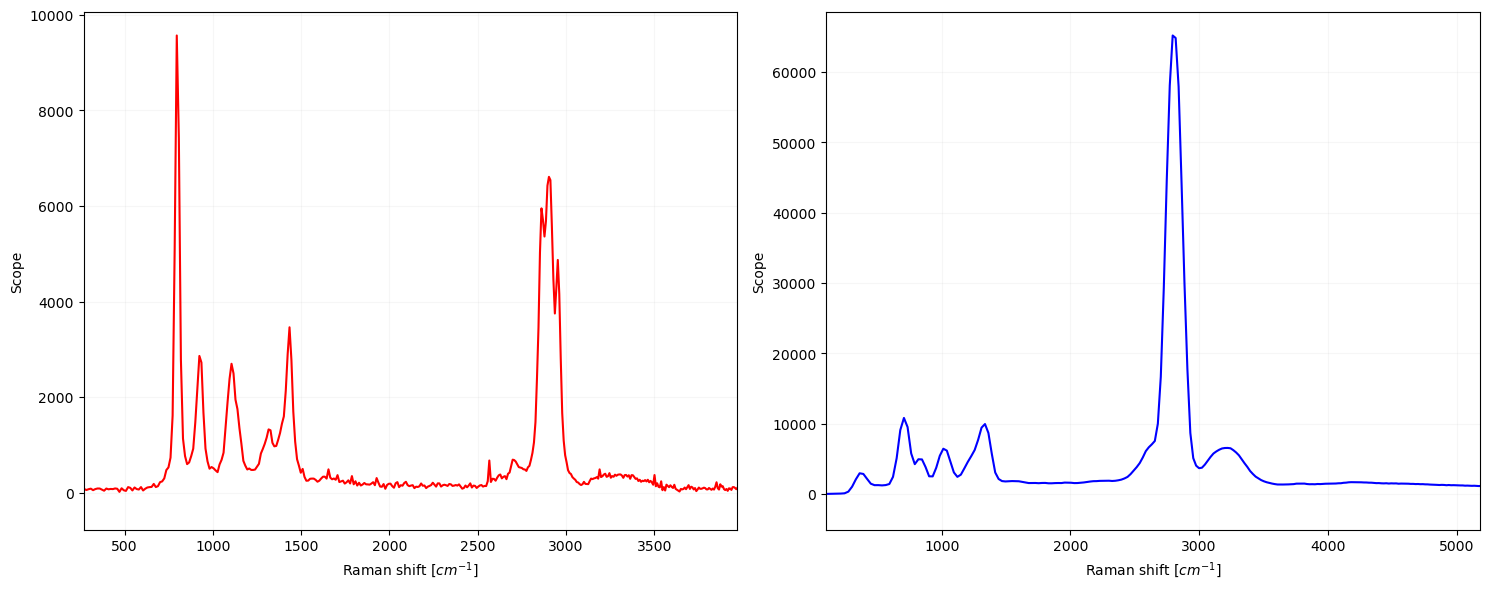

In [197]:
xr_alc, yr_alc = read_txt('AMG/красный лазер пропанол нормальный.txt')
xb_alc, yb_alc = read_txt('AMG/синий лазер пропанол.txt')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(red_raman_shift(xr_alc), yr_alc, c='r')
axes[1].plot(blue_raman_shift(xb_alc), yb_alc, c='b')
axes[0].set_xlabel('Raman shift [$cm^{-1}$]')
axes[1].set_xlabel('Raman shift [$cm^{-1}$]')
axes[0].set_ylabel('Scope')
axes[1].set_ylabel('Scope')
axes[0].set_xlim(red_raman_shift(675), red_raman_shift(900))
axes[1].set_xlim(blue_raman_shift(445), blue_raman_shift(575))
axes[0].grid(alpha=0.1)
axes[1].grid(alpha=0.1)
plt.tight_layout()
plt.show()

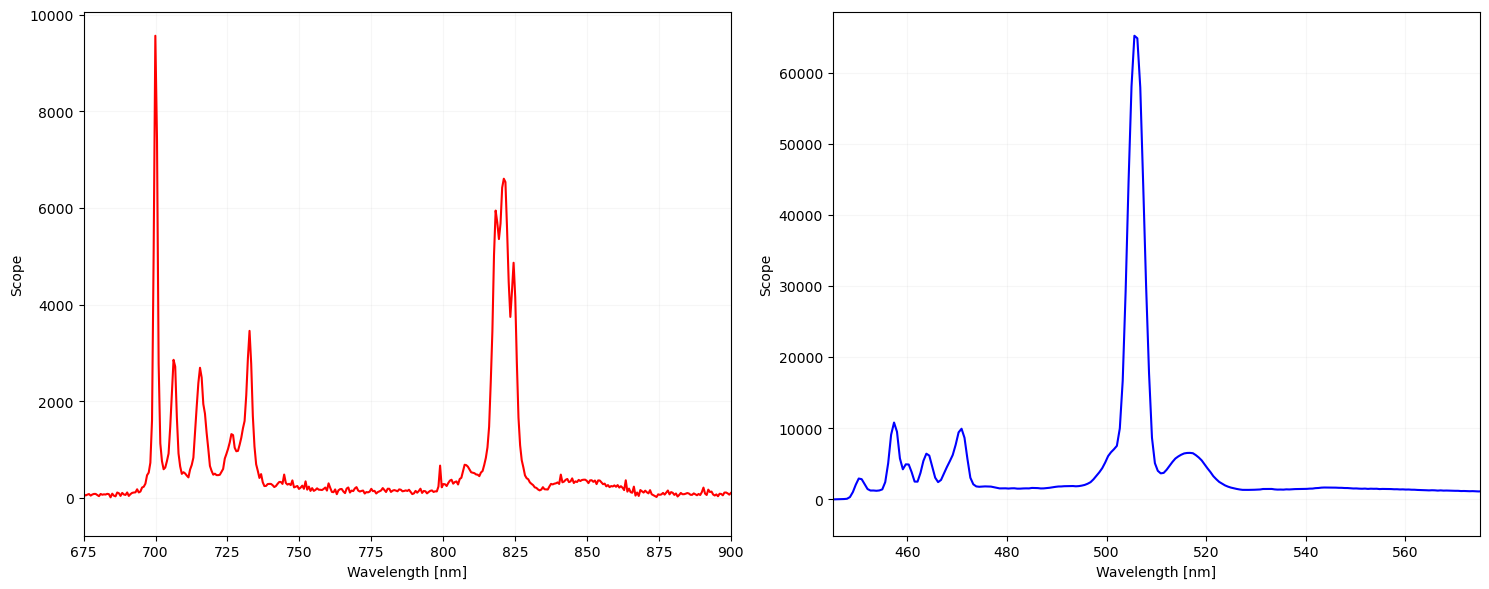

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(xr_alc, yr_alc, c='r')
axes[1].plot(xb_alc, yb_alc, c='b')
axes[0].set_xlabel('Wavelength [nm]')
axes[1].set_xlabel('Wavelength [nm]')
axes[0].set_ylabel('Scope')
axes[1].set_ylabel('Scope')

axes[0].set_xlim(675, 900)
axes[1].set_xlim(445, 575)
axes[0].grid(alpha=0.1)
axes[1].grid(alpha=0.1)
plt.tight_layout()
plt.show()

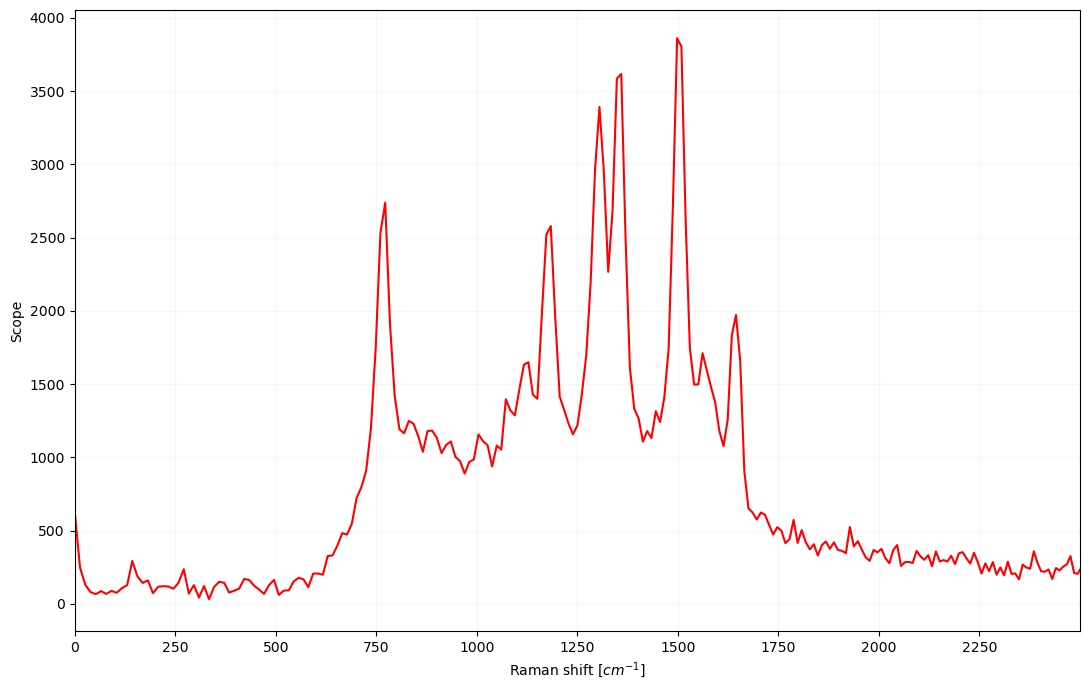

In [7]:
x_sers, y_sers = read_txt('AMG/серебро оч хорошо.txt')
plt.figure(figsize=(11, 7))
plt.plot(red_raman_shift(x_sers), y_sers, c='r')
plt.xlabel("Raman shift [$cm^{-1}$]")
plt.ylabel('Scope')
plt.xlim(0, 2500)
plt.xticks(np.arange(0, 2500, 250))
plt.grid(alpha=0.1)
plt.tight_layout()
plt.show()

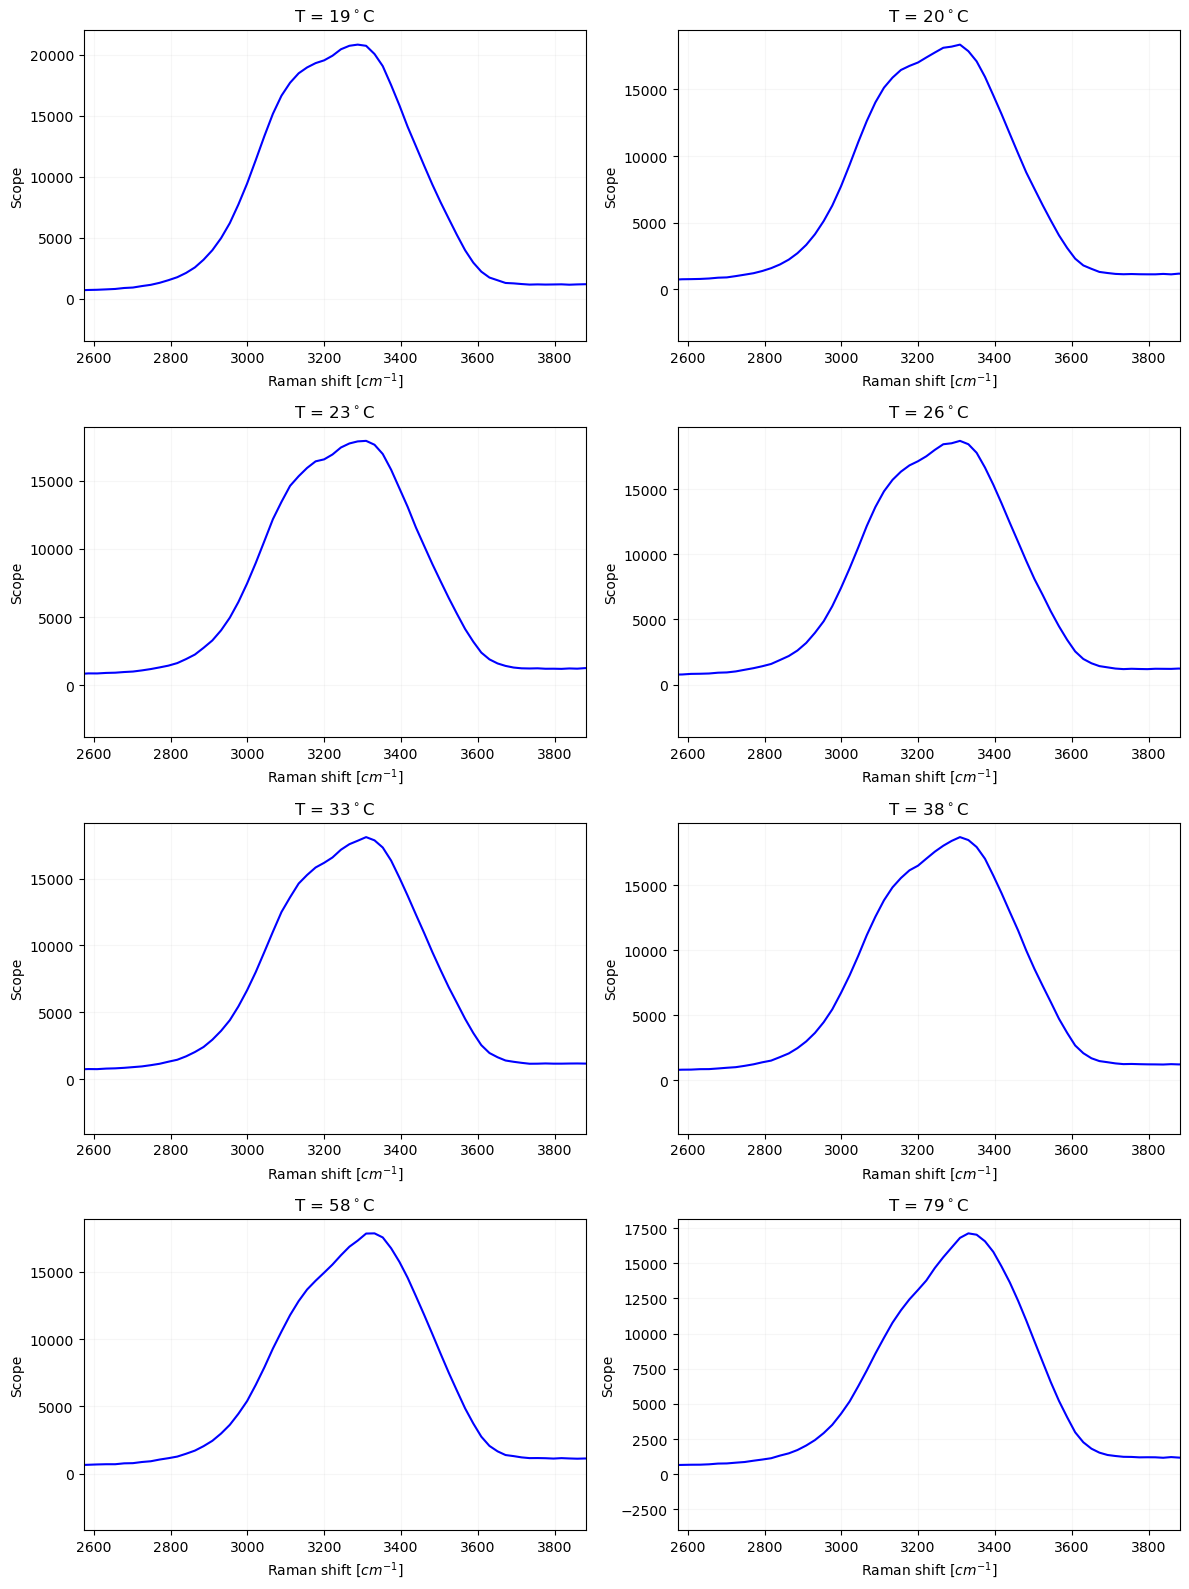

In [8]:
T = np.array([19, 20, 23, 26, 33, 38, 58, 79])

fig, axes = plt.subplots(4, 2, figsize=(12, 16))

for i, t in enumerate(T):
    if not i % 2:
        j = 0
    else:
        j = 1
    i = int(i/2)
    data = read_txt(f"AMG/вода_{t}_градусов.txt")
    axes[i, j].plot(blue_raman_shift(data[0]), data[1], c='b')
    axes[i, j].set_xlim(blue_raman_shift(500), blue_raman_shift(535))
    axes[i, j].set_xlabel('Raman shift [$cm^{-1}$]')
    axes[i, j].set_ylabel('Scope')
    axes[i, j].set_title(f'T = {t}$^\circ$C')
    axes[i, j].grid(alpha=0.1)
    

plt.tight_layout()
plt.show()

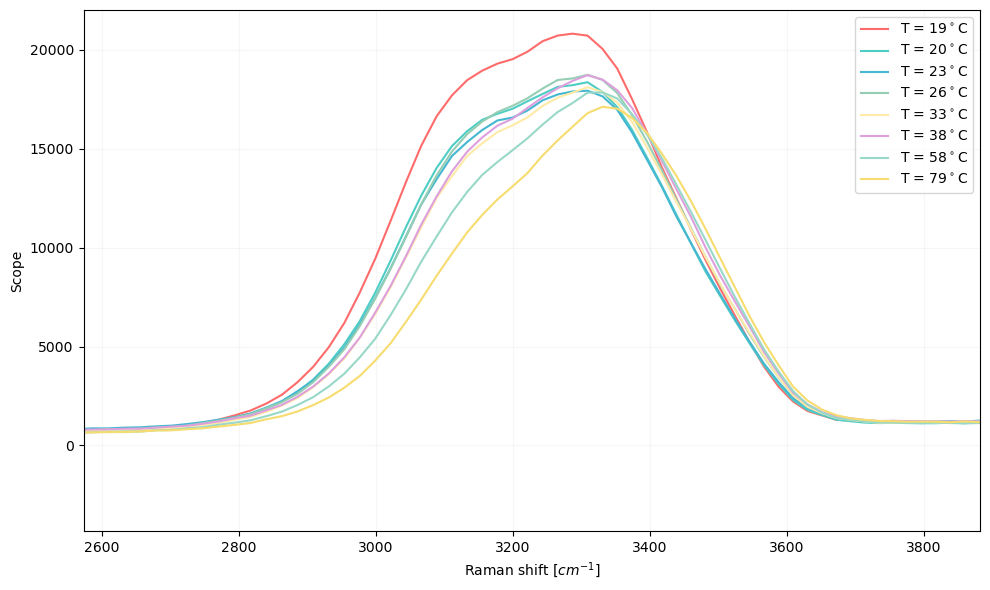

In [9]:
color = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8', '#F7DC6F', '#BB8FCE', '#85C1E9']

plt.figure(figsize=(10, 6))

for i in range(len(T)):
    data = read_txt(f"AMG/вода_{T[i]}_градусов.txt")
    plt.plot(blue_raman_shift(data[0]), data[1], c=color[i], label=f'T = {T[i]}$^\circ$C')

plt.xlabel('Raman shift [$cm^{-1}$]')
plt.ylabel('Scope')
plt.grid(alpha=0.1)
plt.xlim(blue_raman_shift(500), blue_raman_shift(535))
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
def dgauss(x, a1, mu1, sigma1, a2, mu2, sigma2, a3, mu3, sigma3):
    return (a1 * np.exp(-(x-mu1)**2/(2*sigma1**2))
            + a2 * np.exp(-(x-mu2)**2/(2*sigma2**2))
            + a3 * np.exp(-(x-mu3)**2/(2*sigma3**2)))

def gauss_decomposition(filename, left, right):
    with open(filename, encoding='utf-8') as f:
        lines = f.readlines()
    start = 0
    for i, line in enumerate(lines):
        if '[nm]' in line:
            start = i + 1
            break
    
    colnames = ['Wave', 'Sample', 'Dark', 'Reference', 'Scope']
    
    data = pd.read_csv(
        filename,
        sep=';',
        skiprows=start,
        skipinitialspace=True,
        names=colnames,
        engine='python'
    )
    
    mask = (data['Wave'] > left) & (data['Wave'] < right)
    x = blue_raman_shift(data['Wave'][mask].values)
    y = data['Scope'][mask].values
    
    
    p0 = [max(y)/1.3, x[np.argmax(y)]+200, 20, max(y)/1.2, x[np.argmax(y)]-200, 20, max(y)/2, x[np.argmax(y)]+600, 20]  
    popt, pcov = curve_fit(dgauss, x, y, p0=p0)
    
    return popt, pcov

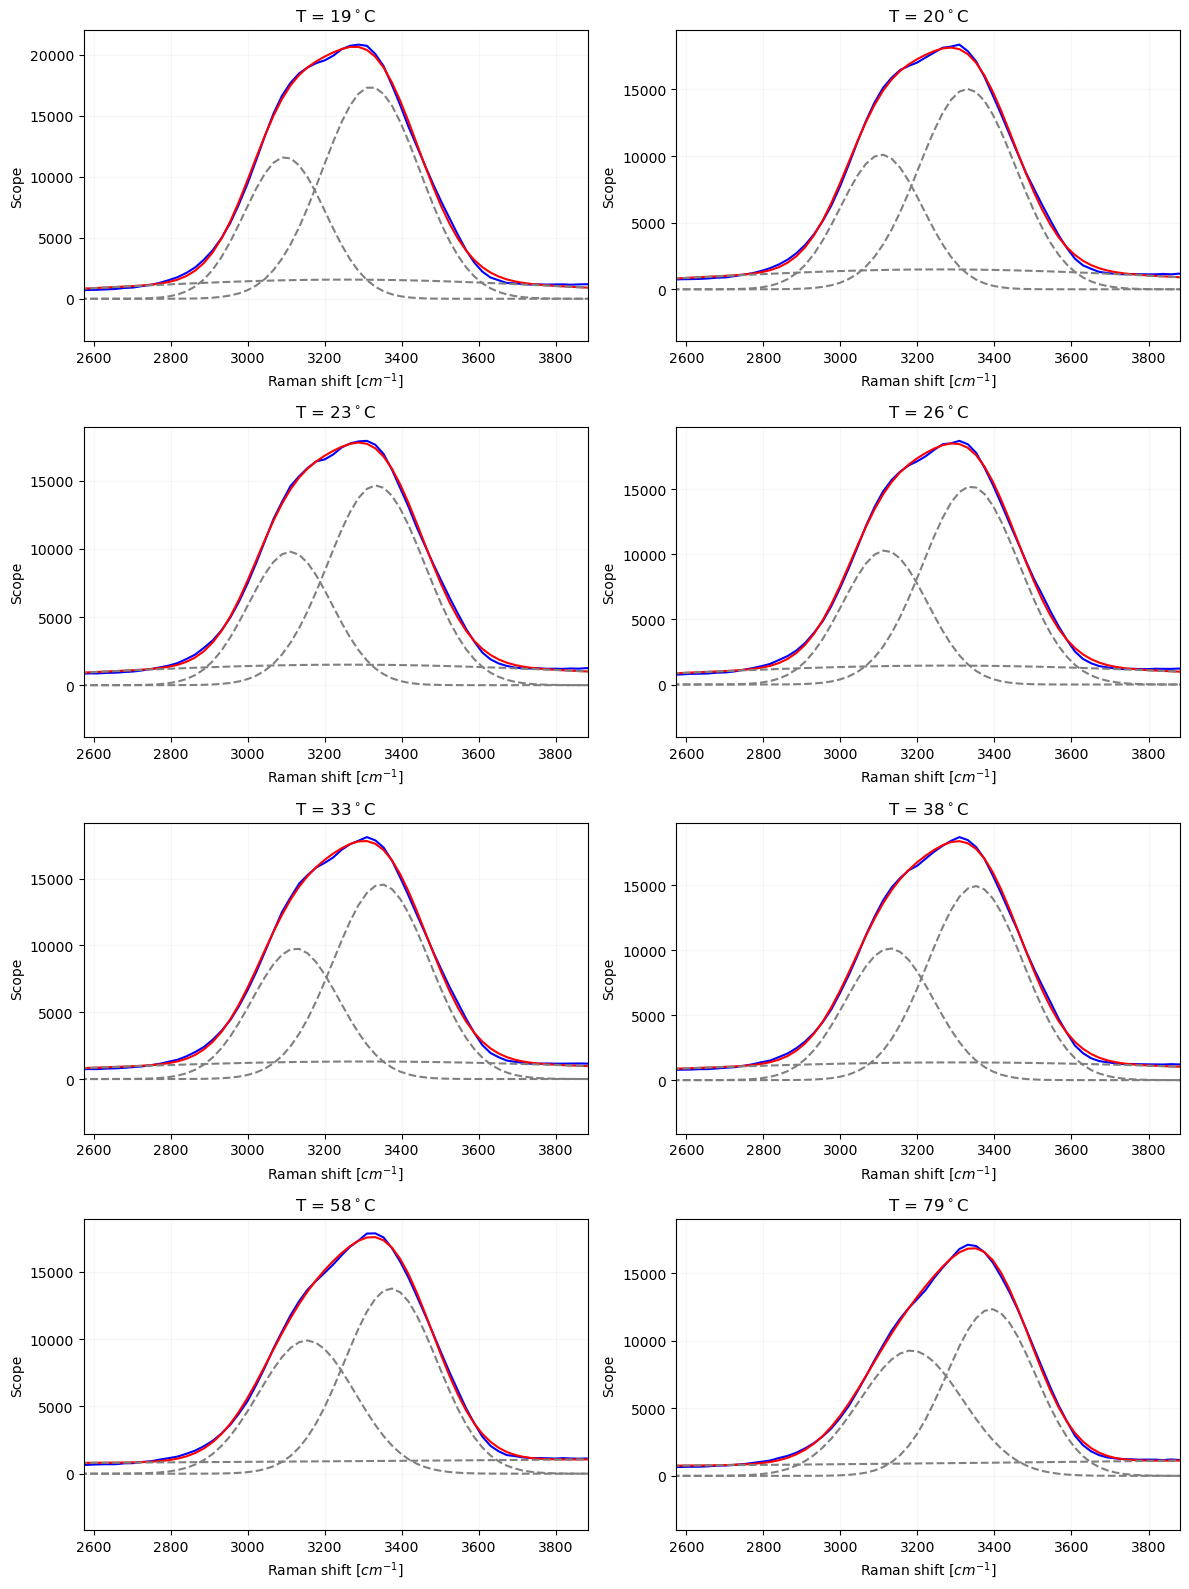

In [23]:
T = np.array([19, 20, 23, 26, 33, 38, 58, 79])
fig, axes = plt.subplots(4, 2, figsize=(12, 16))

integral_ratio = []
integral_ratio_error = [] 
lpeak = []
rpeak = []
lsigma = []
rsigma = []

for i, t in enumerate(T):
    if not i % 2:
        j = 0
    else:
        j = 1
    i = int(i/2)
    
    data = read_txt(f'AMG/вода_{t}_градусов.txt')
    x = blue_raman_shift(data[0])
    y = data[1]
    params, covariance = gauss_decomposition(f'AMG/вода_{t}_градусов.txt', 500, 535)
    a1, mu1, sigma1, a2, mu2, sigma2, a3, mu3, sigma3 = params
    
    errors = np.sqrt(np.diag(covariance))
    a1_err, mu1_err, sigma1_err, a2_err, mu2_err, sigma2_err, a3_err, mu3_err, sigma3_err = errors
    
    S1 = abs(a1 * sigma1 * np.sqrt(2*np.pi))
    S2 = abs(a2 * sigma2 * np.sqrt(2*np.pi))
    ratio = S1 / S2
    integral_ratio.append(ratio)
    
    S1_error = S1 * np.sqrt((a1_err/a1)**2 + (sigma1_err/sigma1)**2)
    S2_error = S2 * np.sqrt((a2_err/a2)**2 + (sigma2_err/sigma2)**2)
    ratio_error = ratio * np.sqrt((S1_error/S1)**2 + (S2_error/S2)**2)
    integral_ratio_error.append(ratio_error)
    rpeak.append(mu1)
    lpeak.append(mu2)
    lsigma.append(sigma2)
    rsigma.append(sigma1)
    
    axes[i, j].plot(x, y, c='b', label='Эксперимент')
    axes[i, j].plot(x, dgauss(x, *params), c='r', label='Сумма функций')
    axes[i, j].plot(x, a1*np.exp(-(x-mu1)**2/(2*sigma1**2)), '--', c='gray', label='Гауссианы')
    axes[i, j].plot(x, a2*np.exp(-(x-mu2)**2/(2*sigma2**2)), '--', c='gray')
    axes[i, j].plot(x, a3*np.exp(-(x-mu3)**2/(2*sigma3**2)), '--', c='gray')
    
    axes[i, j].set_xlim(blue_raman_shift(500), blue_raman_shift(535))
    axes[i, j].set_xlabel('Raman shift [$cm^{-1}$]')
    axes[i, j].set_ylabel('Scope')
    axes[i, j].set_title(f'T = {t}$^\circ$C')
    axes[i, j].grid(alpha=0.1)
    
plt.tight_layout()
plt.show()

integral_ratio_error = np.array(integral_ratio_error) / np.array(integral_ratio)

In [30]:
df = pd.DataFrame({'Т, [К]': T,
                  '$S_1/S_2$': integral_ratio,
                  'ln($S_1/S_2$)': np.log(integral_ratio),
                  'Lpeak coordinate, $cm^{-1}$': lpeak,
                  'Rpeak coordinate, $cm^{-1}$': rpeak,
                  '$\sigma_L$, $cm^{-1}$': lsigma,
                  '$\sigma_R$, $cm^{-1}$': rsigma})
df.T

,0,1,2,3,4,5,6,7
"Т, [К]",19.000000,20.000000,23.000000,26.000000,33.000000,38.000000,58.000000,79.000000
$S_1/S_2$,1.792422,1.755063,1.741144,1.681201,1.642123,1.590293,1.334158,1.151285
ln($S_1/S_2$),0.583568,0.562505,0.554542,0.519508,0.495990,0.463918,0.288301,0.140879
"Lpeak coordinate, $cm^{-1}$",3096.381383,3106.506754,3109.592376,3116.087417,3123.772780,3128.283900,3153.136980,3184.346064
"Rpeak coordinate, $cm^{-1}$",3319.420327,3329.516388,3332.717511,3339.101775,3346.280091,3350.706134,3370.992256,3390.961793
"$\sigma_L$, $cm^{-1}$",105.545937,107.099840,108.501124,110.359860,113.346547,114.505469,125.248334,133.500922
"$\sigma_R$, $cm^{-1}$",126.566014,126.336657,126.183215,125.557103,124.829766,123.575002,120.219454,115.504680


Hydrogen bond energy = 6.20 $\pm$ 0.28, [kJ]


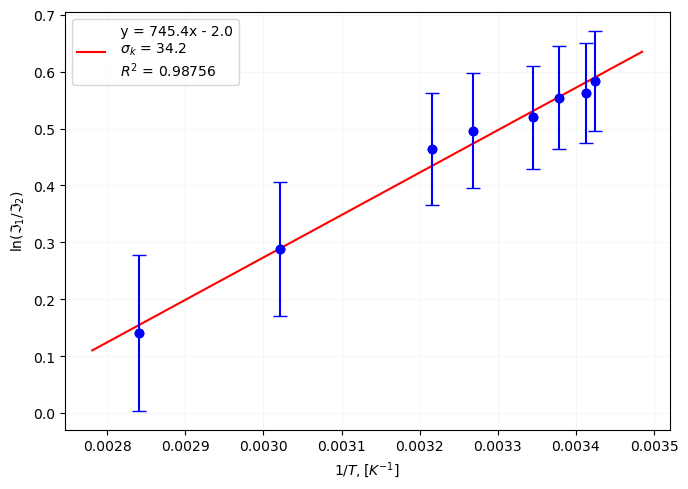

In [13]:
# СУУУУУУКАКААААА МОЕ ЛЮБИМОЕ
T = np.array([19, 20, 23, 26, 33, 38, 58, 79]) + 273

plt.figure(figsize=(7, 5))

plt.scatter(1/T, np.log(integral_ratio), c='b')

p = np.polyfit(1/T, np.log(integral_ratio), 1)
f = np.poly1d(p)
slope, intercept, r_value, p_value, std_err = stats.linregress(1/T, np.log(integral_ratio))
    
    
xxx = np.linspace(min(1/T)-0.00006, max(1/T)+0.00006, 2)
plt.plot(xxx, f(xxx), c='r', label=f' y = {slope:.1f}x - {abs(intercept):.1f}\n $\sigma_k$ = {std_err:.1f}\n $R^2$ = {pow(r_value, 2):.5f}')
plt.errorbar(x=1/T, y=np.log(integral_ratio), yerr=integral_ratio_error, fmt='o', c='b', capsize=5, capthick=1)

print(f"Hydrogen bond energy = {(slope*8.314/1000):.2f} $\pm$ {(std_err*8.314/1000):.2f}, [kJ]")

plt.xlabel('$1/T, [K^{-1}]$')
plt.ylabel('$\ln(\Im_1/\Im_2)$')

plt.grid(alpha=0.1)
plt.legend()
plt.tight_layout()
plt.show()